Linear Regression:
  MAE: 0.66, MSE: 0.74, R² Score: 0.278

KNN:
  MAE: 0.65, MSE: 0.71, R² Score: 0.303

Random Forest:
  MAE: 0.65, MSE: 0.74, R² Score: 0.283

SVR:
  MAE: 0.60, MSE: 0.66, R² Score: 0.352



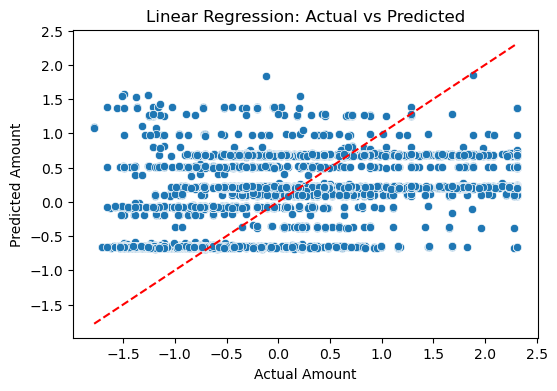

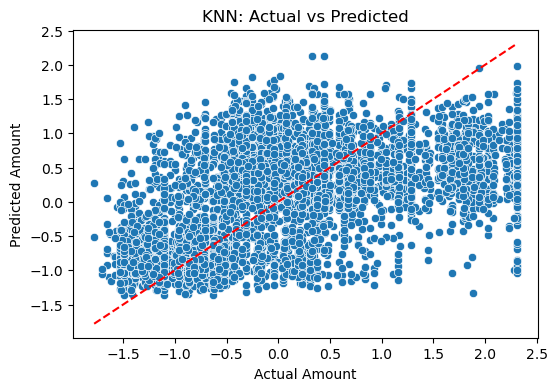

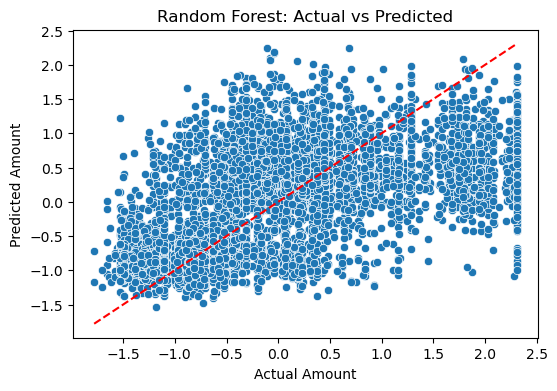

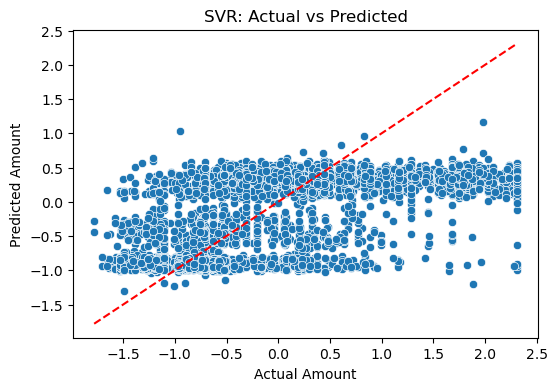

C:\Users\sriya\AppData\Local\Temp\ipykernel_5568\1363876695.py:119: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




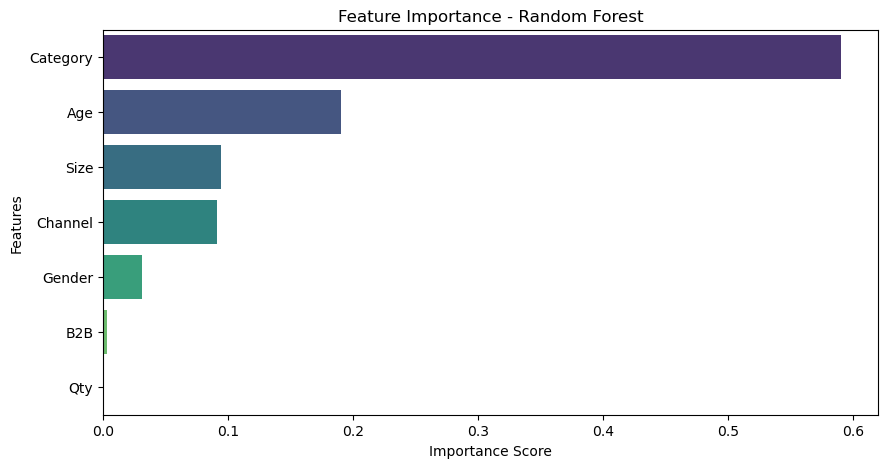

🎯 Best Model: **SVR** with R² Score: 0.352


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Load the dataset
dataset_path = "C:/Users/sriya/Downloads/Fashion_Sales_Cleaned.xlsx"
df = pd.read_excel(dataset_path)

# Cleaning column names
df.columns = df.columns.str.strip()

# Encoding categorical variables
label_encoders = {}
categorical_cols = ['Gender', 'Age Group', 'Month', 'Status', 'Channel', 'Category', 'Size', 'currency', 'ship-country']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Select features and target variable
X = df[['Gender', 'Age', 'Qty', 'Category', 'Channel', 'Size', 'B2B']]
y = df['Amount']

# Splitting data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizing features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Dictionary to store results
results = {}

# ------------------------------
# 1️⃣ LINEAR REGRESSION
# ------------------------------
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
results['Linear Regression'] = {
    'MAE': mean_absolute_error(y_test, y_pred_lr),
    'MSE': mean_squared_error(y_test, y_pred_lr),
    'R2': r2_score(y_test, y_pred_lr)
}

# ------------------------------
# 2️⃣ K-NEAREST NEIGHBORS (KNN)
# ------------------------------
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
results['KNN'] = {
    'MAE': mean_absolute_error(y_test, y_pred_knn),
    'MSE': mean_squared_error(y_test, y_pred_knn),
    'R2': r2_score(y_test, y_pred_knn)
}

# ------------------------------
# 3️⃣ RANDOM FOREST REGRESSOR
# ------------------------------
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
results['Random Forest'] = {
    'MAE': mean_absolute_error(y_test, y_pred_rf),
    'MSE': mean_squared_error(y_test, y_pred_rf),
    'R2': r2_score(y_test, y_pred_rf)
}

# ------------------------------
# 4️⃣ SUPPORT VECTOR REGRESSOR (SVR)
# ------------------------------
svr = SVR(kernel='rbf')
svr.fit(X_train_scaled, y_train)
y_pred_svr = svr.predict(X_test_scaled)
results['SVR'] = {
    'MAE': mean_absolute_error(y_test, y_pred_svr),
    'MSE': mean_squared_error(y_test, y_pred_svr),
    'R2': r2_score(y_test, y_pred_svr)
}

# Print model results
for model, metrics in results.items():
    print(f"{model}:")
    print(f"  MAE: {metrics['MAE']:.2f}, MSE: {metrics['MSE']:.2f}, R² Score: {metrics['R2']:.3f}\n")

# ------------------------------
# 📊 VISUALIZATIONS
# ------------------------------
# Function to plot actual vs predicted

def plot_actual_vs_predicted(y_actual, y_pred, title):
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=y_actual, y=y_pred)
    plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--')
    plt.xlabel("Actual Amount")
    plt.ylabel("Predicted Amount")
    plt.title(title)
    plt.show()

# Plot results for each model
plot_actual_vs_predicted(y_test, y_pred_lr, "Linear Regression: Actual vs Predicted")
plot_actual_vs_predicted(y_test, y_pred_knn, "KNN: Actual vs Predicted")
plot_actual_vs_predicted(y_test, y_pred_rf, "Random Forest: Actual vs Predicted")
plot_actual_vs_predicted(y_test, y_pred_svr, "SVR: Actual vs Predicted")

# Feature importance for Random Forest
feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=feature_importance, y=feature_importance.index, palette="viridis")
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

# ------------------------------
# 📌 INSIGHTS
# ------------------------------
best_model = max(results, key=lambda k: results[k]['R2'])
print(f"🎯 Best Model: **{best_model}** with R² Score: {results[best_model]['R2']:.3f}")
